# Version 1 Termination Generator Audit

This notebook presents the diagnostic results produced by
`src/audit_termination_generator.py`.

The audit examines the production generator used to create the 10,000-employee synthetic workforce. It distinguishes variables that directly determine termination from behavioral relationships created after the termination outcome has already been assigned.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


candidate_roots = [
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = next(
    path
    for path in candidate_roots
    if (
        path
        / "data"
        / "processed"
        / "audit"
    ).exists()
)

AUDIT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "audit"
)

summary = pd.read_csv(
    AUDIT_DIR / "generator_audit_summary.csv"
)

organizational = pd.read_csv(
    AUDIT_DIR
    / "attrition_by_organizational_level.csv"
)

tenure = pd.read_csv(
    AUDIT_DIR / "attrition_by_tenure_rule.csv"
)

department = pd.read_csv(
    AUDIT_DIR / "attrition_by_department.csv"
)

location = pd.read_csv(
    AUDIT_DIR / "attrition_by_location.csv"
)

behavioral = pd.read_csv(
    AUDIT_DIR / "behavioral_associations.csv"
)

termination_month = pd.read_csv(
    AUDIT_DIR / "termination_by_month.csv"
)

audit_display = AUDIT_DIR.relative_to(PROJECT_ROOT).as_posix()
print(f"Audit directory: {audit_display}")

Audit directory: data/processed/audit


In [2]:
display(summary)
display(organizational)
display(tenure)
display(department)
display(location)
display(behavioral)

,metric,value
0,Total employees,10000.000000
1,Terminated employees,1713.000000
2,Observed attrition rate,0.171300
3,Expected terminations from generator,1710.250000
4,Expected attrition rate,0.171025
5,Individual contributors,9158.000000
6,Permanently active leaders,842.000000
7,Individual contributors under 120 days,528.000000
8,Voluntary terminations,1299.000000
9,Involuntary terminations,414.000000


,organizational_level,headcount,terminations,observed_attrition_rate,expected_attrition_rate,individual_contributor_share,rate_difference
0,Individual Contributor,9158,1713,0.18705,0.186749,1.0,0.0003
1,Department Head,8,0,0.00000,0.000000,0.0,0.0000
2,Senior Manager,68,0,0.00000,0.000000,0.0,0.0000
3,Team Manager,766,0,0.00000,0.000000,0.0,0.0000


,tenure_rule_band,headcount,terminations,observed_attrition_rate,expected_attrition_rate,individual_contributor_share,rate_difference
0,365+ days: full probability,8307,1548,0.186349,0.184193,0.89864,0.002156
1,120–364 days: reduced probability,1165,165,0.141631,0.154644,1.00000,-0.013013
2,0–119 days: forced active,528,0,0.000000,0.000000,1.00000,0.000000


,department_name,headcount,terminations,observed_attrition_rate,expected_attrition_rate,individual_contributor_share,rate_difference
0,Manufacturing,2499,528,0.211285,0.206190,0.916767,0.005094
1,Customer Support,800,155,0.193750,0.204937,0.915000,-0.011187
2,Information Technology,1000,164,0.164000,0.154860,0.915000,0.009140
3,Supply Chain,1200,185,0.154167,0.153592,0.915833,0.000575
4,Sales,1000,153,0.153000,0.153410,0.915000,-0.000410
5,Engineering,2000,305,0.152500,0.154380,0.916500,-0.001880
6,Finance,800,122,0.152500,0.152213,0.915000,0.000287
7,Human Resources,701,101,0.144080,0.153951,0.914408,-0.009872


,location_name,headcount,terminations,observed_attrition_rate,expected_attrition_rate,individual_contributor_share,rate_difference
0,Reno,1737,319,0.183650,0.189286,0.904433,-0.005636
1,Austin,2822,507,0.179660,0.166690,0.915663,0.012970
2,Fremont,2451,413,0.168503,0.165630,0.916769,0.002872
3,Phoenix,1770,289,0.163277,0.170203,0.922034,-0.006927
4,Buffalo,1220,185,0.151639,0.167082,0.921311,-0.015443


,employees,average_days_since_hire,average_performance_rating,average_latest_performance_rating,average_compensation_growth,average_completed_training_count,average_training_hours,average_promotion_events,average_manager_change_events,average_transfer_events,group
0,8287,1012.075781,3.500545,3.522708,0.122609,2.415229,32.711693,0.233981,0.066852,0.057439,Active
1,1713,1104.038529,3.335886,3.354842,0.061288,2.307064,29.062580,0.120841,0.045534,0.044950,Terminated


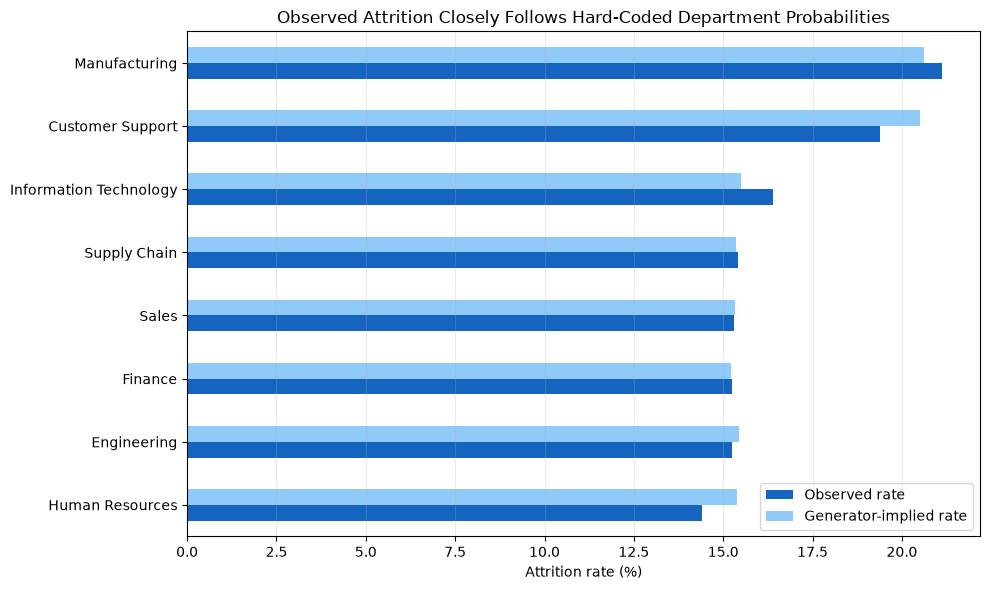

In [3]:
department_plot = (
    department
    .set_index("department_name")
    [
        [
            "observed_attrition_rate",
            "expected_attrition_rate",
        ]
    ]
    .sort_values(
        "observed_attrition_rate"
    )
    * 100
)

ax = department_plot.plot(
    kind="barh",
    figsize=(10, 6),
    color=["#1565C0", "#90CAF9"],
)

ax.set_title(
    "Observed Attrition Closely Follows "
    "Hard-Coded Department Probabilities"
)
ax.set_xlabel("Attrition rate (%)")
ax.set_ylabel("")
ax.legend(
    [
        "Observed rate",
        "Generator-implied rate",
    ]
)
ax.grid(
    axis="x",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

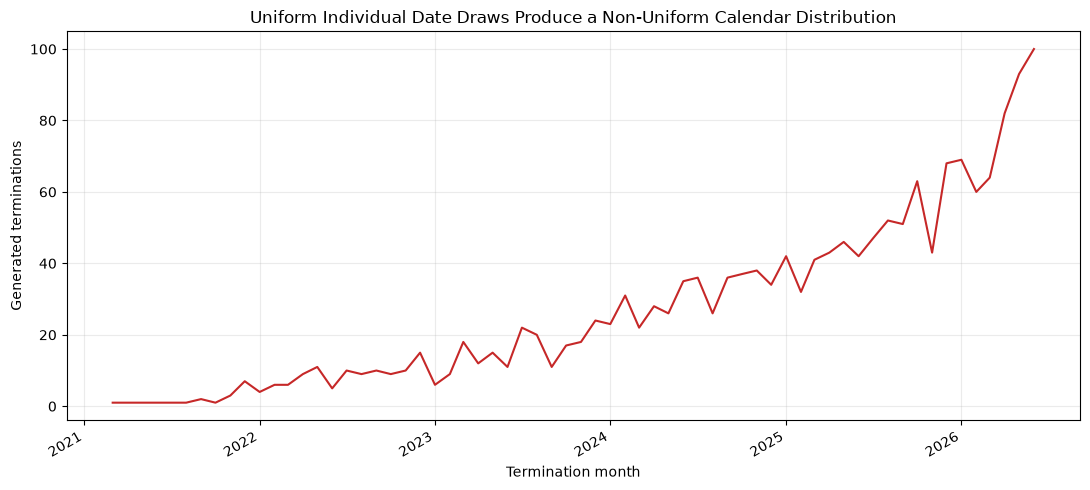

In [4]:
termination_month["termination_month"] = (
    pd.to_datetime(
        termination_month[
            "termination_month"
        ]
    )
)

ax = termination_month.plot(
    x="termination_month",
    y="terminations",
    figsize=(11, 5),
    legend=False,
    color="#C62828",
)

ax.set_title(
    "Uniform Individual Date Draws Produce "
    "a Non-Uniform Calendar Distribution"
)
ax.set_xlabel("Termination month")
ax.set_ylabel("Generated terminations")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Audit Conclusions

1. The production outcome is assigned before performance, compensation, training, promotion, transfer, and manager-change histories are generated.
2. Only individual contributors can terminate; all 842 leaders are structurally forced active.
3. Employees below 120 days of service are forced active, creating an abrupt eligibility cliff.
4. A second discontinuity occurs at 365 days because the five-percentage-point reduction disappears.
5. Manufacturing and Customer Support receive a hard-coded six-percentage-point increase.
6. Reno receives a hard-coded three-percentage-point increase.
7. Termination dates are sampled uniformly within employee-specific intervals, producing an artificial calendar-time distribution.
8. Downstream records stop at termination, giving terminated employees systematically shorter exposure to raises, reviews, training, and internal events.
9. Performance generation directly conditions on termination type, making part of the apparent performance signal outcome-generated.
10. Version 1 model performance therefore measures how effectively models recover synthetic rules and downstream artifacts, not independent real-world attrition behavior.